## Linear Regression Analysis

By Naomi Ortega

This notebook contains analysis of the factors influencing salary in AI roles using linear regression.

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
import statsmodels.api as sm
import numpy as np
import scipy.stats as stats

In [13]:
data = pd.read_csv('ai_jobs_market_2025_2026.csv')

#Create log salary- Since annual salary is skewed, we will use the log of annual salary.
data['log_salary'] = np.log(data['annual_salary_usd'])
data.head()


,job_id,job_title,job_category,experience_level,years_of_experience,education_required,annual_salary_usd,salary_min_usd,salary_max_usd,city,...,demand_score,demand_growth_yoy_pct,benefits_score_10,posting_year,posting_month,is_senior,is_remote_friendly,is_llm_role,salary_tier,log_salary
0,AIJOB0001,AI Agent Developer,AI Engineering,Senior (6-9 yrs),7,Master's,239000.0,155000,290000,Boston,...,96,16.9,6.8,2026,3,1,0,1,Senior ($200-300k),12.384219
1,AIJOB0002,Prompt Engineer,AI Engineering,Senior (6-9 yrs),2,Bachelor's,166000.0,90000,200000,London,...,82,11.6,6.2,2026,1,1,1,1,Upper-Mid ($150-200k),12.019743
2,AIJOB0003,LLM Engineer,AI Engineering,Senior (6-9 yrs),4,Associate's,360000.0,160000,300000,Seattle,...,98,42.7,7.7,2026,1,1,1,1,Elite (>$300k),12.793859
3,AIJOB0004,Data Engineer (AI),Data Engineering,Senior (6-9 yrs),3,Bachelor's,161000.0,130000,220000,Singapore,...,88,6.7,9.5,2026,3,1,1,0,Upper-Mid ($150-200k),11.989160
4,AIJOB0005,AI Product Manager,Product,Lead (10+ yrs),5,Bootcamp/Self-taught,283000.0,140000,260000,Los Angeles,...,85,17.3,8.9,2026,1,1,1,0,Senior ($200-300k),12.553202


In [ ]:
data.columns

Index(['job_id', 'job_title', 'job_category', 'experience_level',
       'years_of_experience', 'education_required', 'annual_salary_usd',
       'salary_min_usd', 'salary_max_usd', 'city', 'country', 'remote_work',
       'company_size', 'industry', 'required_skills', 'ai_salary_premium_pct',
       'demand_score', 'demand_growth_yoy_pct', 'benefits_score_10',
       'posting_year', 'posting_month', 'is_senior', 'is_remote_friendly',
       'is_llm_role', 'salary_tier', 'log_salary'],
      dtype='str')

## Linear Regression Model

We will use multivariate linear regression to see which variables have an effect on salary.  

### Variable selection

We want to select the variables that are relevant for predicting annual salary. We will use regularization using elastic net penalty for variable selection.


First, before putting the data through regularization, we create a new dataframe, which contains the response variable `log_salary` and only the subsection of the variables that are possible to use as covariates to predict log salary.

The changes from the original dataset `data` to the new dataframe `subdata` are
- Drop `job_id`
- Drop `required_skills` because it has too many unique values for feasible use in linear regression
- Drop the response variable `annual_salary_usd` (the response variable is now contained in `log_salary`)
- Drop `is_senior` because it is duplicative (and multicollinear) of the experience_level variable which creates dummy variables for each experience level in the regression model.
- Drop `is_remote_friendly` because it is duplicative of `remote_work` and therefore multicollinear
- Drop the **salary-related** variables: `salary_min_usd, salary_max_usd, ai_salary_premium_pct, salary_tier`
- Drop `posting_month` and `posting_year` since we will not be considering the recency of the posting as a predictor of salary


In [31]:
subdata = data.drop(columns = ['job_id', 'required_skills','annual_salary_usd', 'is_senior', 'is_remote_friendly', 'salary_min_usd','salary_max_usd','ai_salary_premium_pct','salary_tier', 'posting_month', 'posting_year'])
subdata.head()

,job_title,job_category,experience_level,years_of_experience,education_required,city,country,remote_work,company_size,industry,demand_score,demand_growth_yoy_pct,benefits_score_10,is_llm_role,log_salary
0,AI Agent Developer,AI Engineering,Senior (6-9 yrs),7,Master's,Boston,USA,On-site,Startup (1-50),Finance,96,16.9,6.8,1,12.384219
1,Prompt Engineer,AI Engineering,Senior (6-9 yrs),2,Bachelor's,London,UK,Hybrid,Enterprise (5000+),Finance,82,11.6,6.2,1,12.019743
2,LLM Engineer,AI Engineering,Senior (6-9 yrs),4,Associate's,Seattle,USA,Fully Remote,Big Tech (FAANG+),Finance,98,42.7,7.7,1,12.793859
3,Data Engineer (AI),Data Engineering,Senior (6-9 yrs),3,Bachelor's,Singapore,Singapore,Fully Remote,SME (51-500),Technology,88,6.7,9.5,0,11.989160
4,AI Product Manager,Product,Lead (10+ yrs),5,Bootcamp/Self-taught,Los Angeles,USA,Fully Remote,Enterprise (5000+),Automotive,85,17.3,8.9,0,12.553202


In [32]:
#Now the variables contained in subdata are:
subdata.columns

Index(['job_title', 'job_category', 'experience_level', 'years_of_experience',
       'education_required', 'city', 'country', 'remote_work', 'company_size',
       'industry', 'demand_score', 'demand_growth_yoy_pct',
       'benefits_score_10', 'is_llm_role', 'log_salary'],
      dtype='str')

### Shrinkage Methods
Now, we preform variable selection using regularization with the elastic net penalty.

In [33]:
full_model_formula = 'log_salary ~ ' + ' + '.join([c for c in subdata.columns if c != 'log_salary'])
full_model_formula

'log_salary ~ job_title + job_category + experience_level + years_of_experience + education_required + city + country + remote_work + company_size + industry + demand_score + demand_growth_yoy_pct + benefits_score_10 + is_llm_role'

Hyperparameter selection- optimal regularization strength

In [17]:
## hyperparameter selection for regularization parameter

from sklearn.model_selection import train_test_split
train, test = train_test_split(subdata, test_size = 0.25, random_state = 0)
train.shape, test.shape

def cv_error(alpha, l1wt, train, test):
    model = smf.ols(full_model_formula, data=train).\
                fit_regularized(method='elastic_net', alpha=alpha, L1_wt=l1wt)
    yhat_test = model.predict(test)
    error = np.sum((test['log_salary'] - yhat_test) ** 2)
    return error

In [34]:
l1wt = 1.0
alphas = np.linspace(1e-3, 0.5, 200)
cv_errors = np.zeros_like(alphas)

for (i, alpha) in enumerate(alphas):
    cv_errors[i] = cv_error(alpha, l1wt, train, test)

0 0.001
Optimal alpha: 0.001, CV Error: 6.0152654356005115


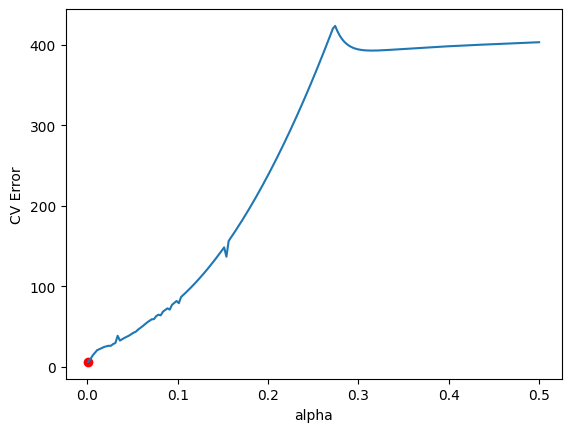

In [35]:
plt.plot(alphas, cv_errors)
print(np.argmin(cv_errors), alphas[np.argmin(cv_errors)])

print(f'Optimal alpha: {alphas[np.argmin(cv_errors)]}, CV Error: {cv_errors[np.argmin(cv_errors)]}')
plt.scatter(alphas[np.argmin(cv_errors)], cv_errors[np.argmin(cv_errors)], color='red')
plt.xlabel('alpha')
plt.ylabel('CV Error');

Using the optimal alpha obtained through cross-validation, apply the elastic net shrinkage method to obtain the useful covariates.

In [36]:
elastic_net = smf.ols(full_model_formula, data=subdata).\
                fit_regularized(method='elastic_net', alpha=alphas[np.argmin(cv_errors)], L1_wt=1.0)

Results:
### Nonmeaningful variables
Variables with 0 coefficients

In [39]:
print(elastic_net.params[elastic_net.params == 0])

job_title[T.AI Ethics Officer]         0.0
job_title[T.AI Product Manager]        0.0
job_title[T.AI Research Scientist]     0.0
job_title[T.AI Security Engineer]      0.0
job_title[T.Deep Learning Engineer]    0.0
job_title[T.Generative AI Engineer]    0.0
job_title[T.ML Engineer]               0.0
job_title[T.MLOps Engineer]            0.0
job_title[T.RAG Engineer]              0.0
job_title[T.Senior Data Scientist]     0.0
job_category[T.Architecture]           0.0
job_category[T.Business]               0.0
job_category[T.Data Engineering]       0.0
job_category[T.Data Science]           0.0
job_category[T.Infrastructure]         0.0
job_category[T.ML Operations]          0.0
job_category[T.Product]                0.0
job_category[T.Research]               0.0
job_category[T.Robotics]               0.0
job_category[T.Security]               0.0
education_required[T.Bachelor's]       0.0
education_required[T.Master's]         0.0
city[T.Austin]                         0.0
city[T.Bost

The shrinkage algorithm determined that 
* Many, but not all, of job roles, job categories, industries, countries, and cities, had no significant effect. 
* Education levels Bachelor's and Master's had no effect 
* Hybrid and on-site jobs were not significant predictors of salary

### The meaningful variables
Variables with nonzero coefficients.

In [40]:
print(elastic_net.params[elastic_net.params != 0])

Intercept                                     12.029493
job_title[T.AI Business Analyst]              -0.326527
job_title[T.AI Compliance Manager]            -0.048183
job_title[T.AI Engineer]                      -0.167419
job_title[T.AI Infrastructure Eng]             0.007901
job_title[T.AI Solutions Architect]            0.238844
job_title[T.Computer Vision Engineer]          0.031853
job_title[T.Data Engineer (AI)]               -0.077593
job_title[T.Data Scientist]                   -0.130845
job_title[T.LLM Engineer]                      0.038100
job_title[T.Multimodal AI Engineer]            0.149725
job_title[T.NLP Engineer]                      0.068041
job_title[T.Prompt Engineer]                  -0.393483
job_title[T.Robotics Engineer (AI)]           -0.079631
job_title[T.Senior ML Engineer]                0.221944
job_category[T.Governance]                    -0.205534
experience_level[T.Lead (10+ yrs)]             0.465131
experience_level[T.Mid (3-5 yrs)]              0

* At least 1 of the categories has a nonzero coefficient for the categorical covariates `job_title`, `job_category`, `experience_level`, `education_required`, `city`, `country`, `company_size`, `demand_score`, `demand_growth_yoy_pct`, `benefits_score_10`, `is_llm_role`
* `years_of_experience`, `demand_score`, `demand_growth_yoy_pct`, and `benefits_score_10` had a nonzero but very small coefficients which shows they aren't very impactful, so we will not include them

------------------------------------

## Final model: significant variables

As a result of using variable selection with elastic net to determine the variables that have an effect on annual salary of AI job roles, our final model for our main analysis using multivariate linear regression includes the following variables:

* `job_title`- Role title
* `job_category` - Role category: (Data Science, AI Engineering, etc.)
* `experience_level` - Entry, Mid, Senior, or Lead
* `education_required` - Minimum required education level
* `city` - City location of job
* `country` - Country location of job
* `company_size` - Startup, SME, Mid-size, Enterprise, Big Tech
* `is_llm_role` - binary variable 


But we know that city and country are not independent, so we will only use city or country in the model.

## Fitting the linear model

In [46]:
final_vars = ['job_title','job_category','experience_level','education_required','city','company_size', 'is_llm_role']


final_formula = '''log_salary ~ job_title + job_category + experience_level + C(education_required, Treatment("Bachelor's")) + city + C(company_size, Treatment("Mid-size (501-5000)")) + is_llm_role'''
final_model = smf.ols(final_formula, data = subdata).fit()
print(final_model.summary())

                            OLS Regression Results                            
Dep. Variable:             log_salary   R-squared:                       0.885
Model:                            OLS   Adj. R-squared:                  0.881
Method:                 Least Squares   F-statistic:                     205.8
Date:                Sun, 31 May 2026   Prob (F-statistic):               0.00
Time:                        22:02:28   Log-Likelihood:                 1135.0
No. Observations:                1500   AIC:                            -2160.
Df Residuals:                    1445   BIC:                            -1868.
Df Model:                          54                                         
Covariance Type:            nonrobust                                         
                                                                              coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------

In [42]:
subdata.education_required.value_counts()

education_required
Master's                316
Bachelor's              311
Bootcamp/Self-taught    297
Associate's             296
PhD                     280
Name: count, dtype: int64

In [44]:
subdata.company_size.value_counts()

company_size
Mid-size (501-5000)    312
SME (51-500)           300
Big Tech (FAANG+)      299
Enterprise (5000+)     297
Startup (1-50)         292
Name: count, dtype: int64

### Assessing the Assumptions of the Model and Influential points

Checking for Influential Points: Cook's Distance

<Axes: ylabel='cooks_d'>

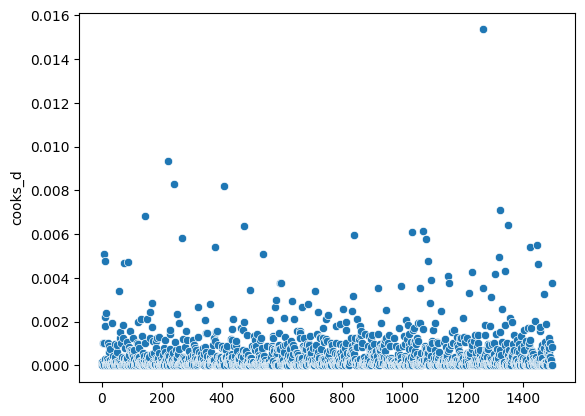

In [49]:
# get influence of points in the dataset
final_model.get_influence().summary_frame()

metric = 'cooks_d'
y = final_model.get_influence().summary_frame()[metric]
x = range(len(y))

sns.scatterplot(y = y, x = x)

### Checking OLS Assumptions

Linearity of Data

Normality

Independence

Heteroscedasticity

## Interpretations:


In [ ]:
#visualizations